<a href="https://colab.research.google.com/github/tarasovEgor/DeepLearningKurs/blob/main/src/lab_4/VAE_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа 4.**

---

## Генерация данных с использованием вариационных автоэнкодеров (VAE).

---

## **Цель работы:** изучить принципы работы вариационных автокодировщиков (VAE) и их применение для генерации новых данных. Также будет проведен анализ латентного пространства и исследованы возможности его интерпретации.


### 0. Init steps

---

#### Импорты библиотек и настройка среды:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Lambda, Layer
from tensorflow.keras.optimizers import Adam

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Подготовка данных

#### 1.1 Загрузка и нормализация MNIST:

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация пикселей из диапазона [0, 255] в диапазон [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Добавляем размерность канала: было (28, 28), стало (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Форма тренировочных данных: {x_train.shape}")
print(f"Форма тестовых данных: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Форма тренировочных данных: (60000, 28, 28, 1)
Форма тестовых данных: (10000, 28, 28, 1)


#### 1.2. Проверка структуры данных:

In [3]:
print(f"Размер тренировочного набора: {x_train.shape}, метки: {y_train.shape}")
print(f"Размер тестового набора: {x_test.shape}, метки: {y_test.shape}")

Размер тренировочного набора: (60000, 28, 28, 1), метки: (60000,)
Размер тестового набора: (10000, 28, 28, 1), метки: (10000,)


#### 1.3. Визуализация первых изображений:

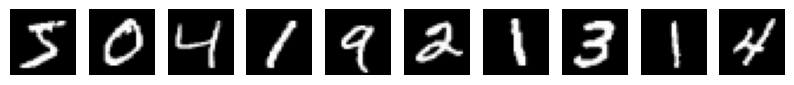

In [4]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()